In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import matplotlib.ticker as mticker


In [9]:
print('hello')

hello


In [10]:


growth_col = "average_value_GDP growth (annual %)"

/var/folders/hq/_tkslfmj2vld7n2rfp92x0wr0000gn/T/ipykernel_95541/3328404881.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Decade", "Group"])["GDP_added"]
/var/folders/hq/_tkslfmj2vld7n2rfp92x0wr0000gn/T/ipykernel_95541/3328404881.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Decade", "Group"])[growth_col]


Group   Share_HI  Share_Dev
Decade                     
1960s       87.6       12.4
1970s       80.7       19.3
1980s       84.1       15.9
1990s       77.8       22.2
2000s       47.9       52.1
2010s       33.6       66.4
Saved → viz_for_barchart.png


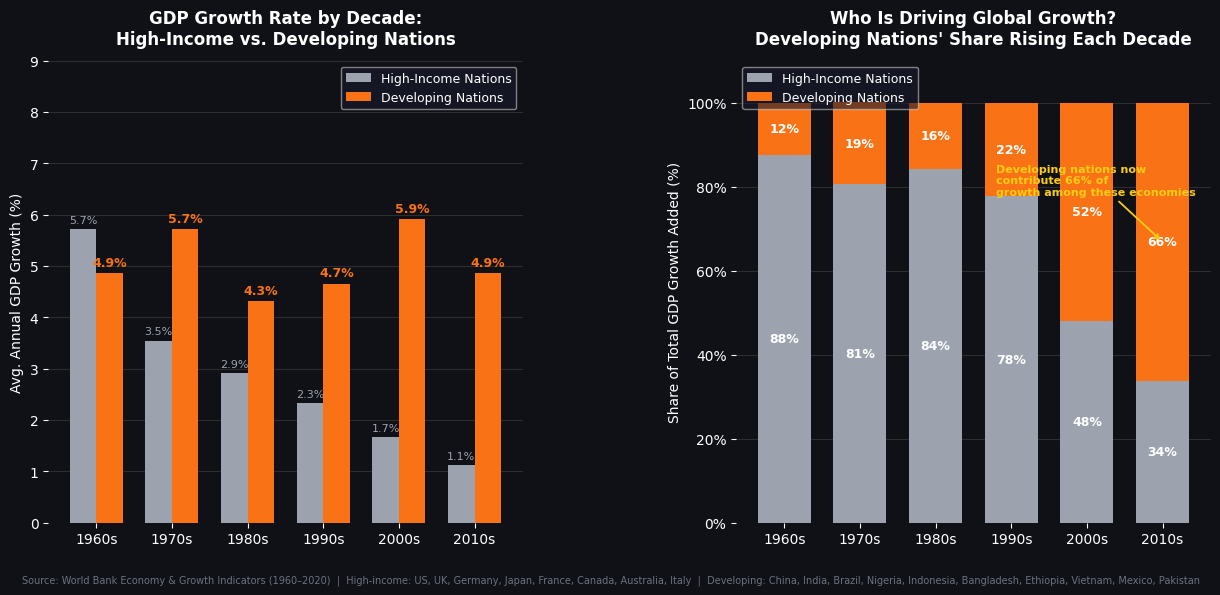

In [11]:
# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv("economy-and-growth.csv")  # change path if needed
df.columns = df.columns.str.strip()

year_col   = "Year"
cname_col  = "Country Name"
gdp_col    = "average_value_GDP (current US$)"
growth_col = "average_value_GDP growth (annual %)"

df = df[[year_col, cname_col, gdp_col, growth_col]].copy()
df[year_col]   = pd.to_numeric(df[year_col],   errors="coerce")
df[gdp_col]    = pd.to_numeric(df[gdp_col],    errors="coerce")
df[growth_col] = pd.to_numeric(df[growth_col], errors="coerce")
df = df.dropna(subset=[year_col, gdp_col, growth_col])
df[year_col] = df[year_col].astype(int)

# ── Country groups ─────────────────────────────────────────────────────────────
high_income = ["United States", "United Kingdom", "Germany", "Japan",
               "France", "Canada", "Australia", "Italy"]

developing  = ["China", "India", "Brazil", "Nigeria", "Indonesia",
               "Bangladesh", "Ethiopia", "Vietnam", "Mexico", "Pakistan"]

all_countries = high_income + developing

df_focus = df[df[cname_col].isin(all_countries)].copy()
df_focus["Group"] = df_focus[cname_col].apply(
    lambda x: "High-Income" if x in high_income else "Developing"
)

# ── Decade bins ────────────────────────────────────────────────────────────────
bins   = [1959, 1969, 1979, 1989, 1999, 2009, 2020]
labels = ["1960s", "1970s", "1980s", "1990s", "2000s", "2010s"]
df_focus["Decade"] = pd.cut(df_focus[year_col], bins=bins, labels=labels)
df_focus = df_focus.dropna(subset=["Decade"])

# ── Compute GDP added per country per year ─────────────────────────────────────
# GDP added ≈ GDP * (growth_rate / 100)
df_focus["GDP_added"] = df_focus[gdp_col] * (df_focus[growth_col] / 100)

# ── Aggregate: total GDP added per group per decade ───────────────────────────
agg = (df_focus
       .groupby(["Decade", "Group"])["GDP_added"]
       .sum()
       .unstack("Group")
       .fillna(0))

# Total GDP added across both groups per decade
agg["Total"] = agg["High-Income"] + agg["Developing"]

# Share of total growth contributed by each group (%)
agg["Share_HI"]  = agg["High-Income"] / agg["Total"] * 100
agg["Share_Dev"] = agg["Developing"]  / agg["Total"] * 100

print(agg[["Share_HI", "Share_Dev"]].round(1))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                         facecolor="#0f1117",
                         gridspec_kw={"wspace": 0.45})

decades = agg.index.tolist()
x       = np.arange(len(decades))
bar_w   = 0.35

# ── LEFT PANEL: Side-by-side average GDP growth rate by decade ────────────────
# (keep this panel the same as before for context)
agg_growth = (df_focus
              .groupby(["Decade", "Group"])[growth_col]
              .mean()
              .unstack("Group"))

ax1 = axes[0]
ax1.set_facecolor("#0f1117")

bars_hi  = ax1.bar(x - bar_w/2, agg_growth["High-Income"], bar_w,
                   color="#9ca3af", label="High-Income Nations", zorder=3)
bars_dev = ax1.bar(x + bar_w/2, agg_growth["Developing"],  bar_w,
                   color="#f97316", label="Developing Nations",  zorder=3)

for bar in bars_hi:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
             f"{bar.get_height():.1f}%", ha="center", va="bottom",
             color="#9ca3af", fontsize=8)
for bar in bars_dev:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
             f"{bar.get_height():.1f}%", ha="center", va="bottom",
             color="#f97316", fontsize=9, fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels(decades, color="white", fontsize=10)
ax1.set_ylabel("Avg. Annual GDP Growth (%)", color="white", fontsize=10)
ax1.set_ylim(0, 9)
ax1.tick_params(colors="white")
ax1.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax1.yaxis.grid(True, color="#2d2d2d", linewidth=0.8, zorder=0)
ax1.set_title("GDP Growth Rate by Decade:\nHigh-Income vs. Developing Nations",
              color="white", fontsize=12, fontweight="bold", pad=12)
ax1.legend(facecolor="#1a1a2e", labelcolor="white",
           framealpha=0.6, fontsize=9, loc="upper right")

# ── RIGHT PANEL: Share of global GDP growth contributed ───────────────────────
ax2 = axes[1]
ax2.set_facecolor("#0f1117")

# Stacked bar: High-Income (gray) on bottom, Developing (orange) on top
bars_bottom = ax2.bar(x, agg["Share_HI"],  bar_w * 2,
                      color="#9ca3af", label="High-Income Nations", zorder=3)
bars_top    = ax2.bar(x, agg["Share_Dev"], bar_w * 2,
                      bottom=agg["Share_HI"],
                      color="#f97316", label="Developing Nations", zorder=3)

# Label each segment
for i, (hi, dev) in enumerate(zip(agg["Share_HI"], agg["Share_Dev"])):
    # High-income label (inside bar, centered)
    ax2.text(i, hi / 2, f"{hi:.0f}%",
             ha="center", va="center",
             color="white", fontsize=9, fontweight="bold")
    # Developing label (inside bar, centered)
    ax2.text(i, hi + dev / 2, f"{dev:.0f}%",
             ha="center", va="center",
             color="white", fontsize=9, fontweight="bold")

# Annotation on last bar highlighting developing share growth
last_dev = agg["Share_Dev"].iloc[-1]
last_hi  = agg["Share_HI"].iloc[-1]
ax2.annotate(f"Developing nations now\ncontribute {last_dev:.0f}% of\ngrowth among these economies",
             xy=(len(decades) - 1, last_hi + last_dev / 2),
             xytext=(len(decades) - 3.2, 78),
             color="#facc15", fontsize=8, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="#facc15", lw=1.3))

ax2.set_xticks(x)
ax2.set_xticklabels(decades, color="white", fontsize=10)
ax2.set_ylabel("Share of Total GDP Growth Added (%)", color="white", fontsize=10)
ax2.set_ylim(0, 110)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f"{val:.0f}%"))
ax2.tick_params(colors="white")
ax2.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax2.yaxis.grid(True, color="#2d2d2d", linewidth=0.8, zorder=0)
ax2.set_title("Who Is Driving Global Growth?\nDeveloping Nations' Share Rising Each Decade",
              color="white", fontsize=12, fontweight="bold", pad=12)
ax2.legend(facecolor="#1a1a2e", labelcolor="white",
           framealpha=0.6, fontsize=9, loc="upper left")

# ── Source note ────────────────────────────────────────────────────────────────
fig.text(0.5, 0.01,
         "Source: World Bank Economy & Growth Indicators (1960–2020)  |  "
         "High-income: US, UK, Germany, Japan, France, Canada, Australia, Italy  |  "
         "Developing: China, India, Brazil, Nigeria, Indonesia, Bangladesh, Ethiopia, Vietnam, Mexico, Pakistan",
         ha="center", color="#6b7280", fontsize=7)

plt.savefig("viz_for_barchart.png",
            dpi=180, bbox_inches="tight", facecolor="#0f1117")
print("Saved → viz_for_barchart.png")
plt.show()